# **Finding Correlation**

In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.

## Objectives

In this lab, you will perform the following:

- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.

##### Step 1: Install and Import Required Libraries

In [2]:
# Install the necessary libraries
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset

In [3]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>

**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.

In [4]:
# Convert compensation column to numeric

df['ConvertedCompYearly'] = pd.to_numeric(
    df['ConvertedCompYearly'],
    errors='coerce'
)

In [5]:
# Remove missing values

comp_data = df['ConvertedCompYearly'].dropna()

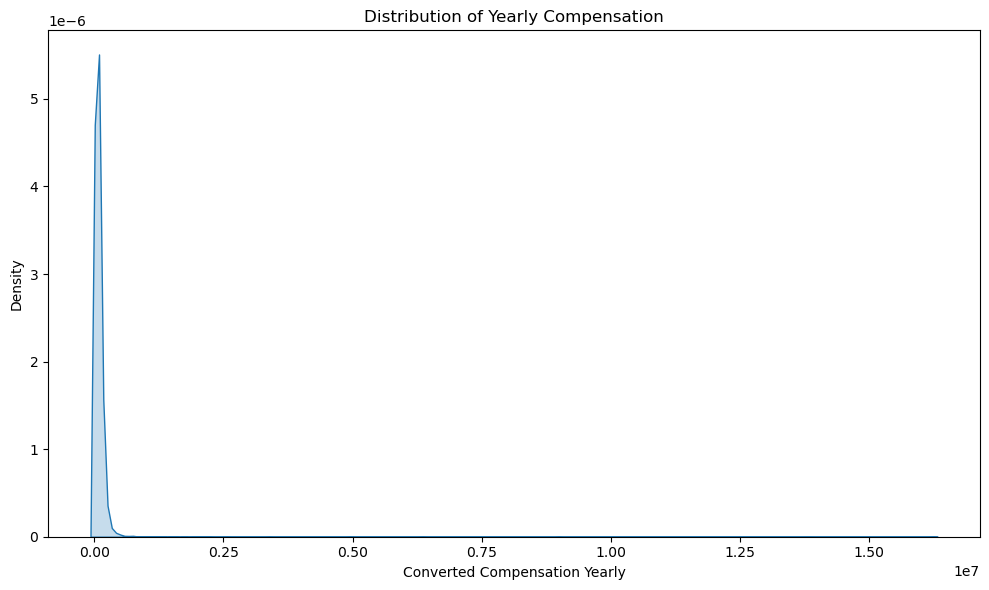

In [6]:
# Plot distribution curve

plt.figure(figsize=(10,6))

sns.kdeplot(
    comp_data,
    fill=True
)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('Converted Compensation Yearly')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

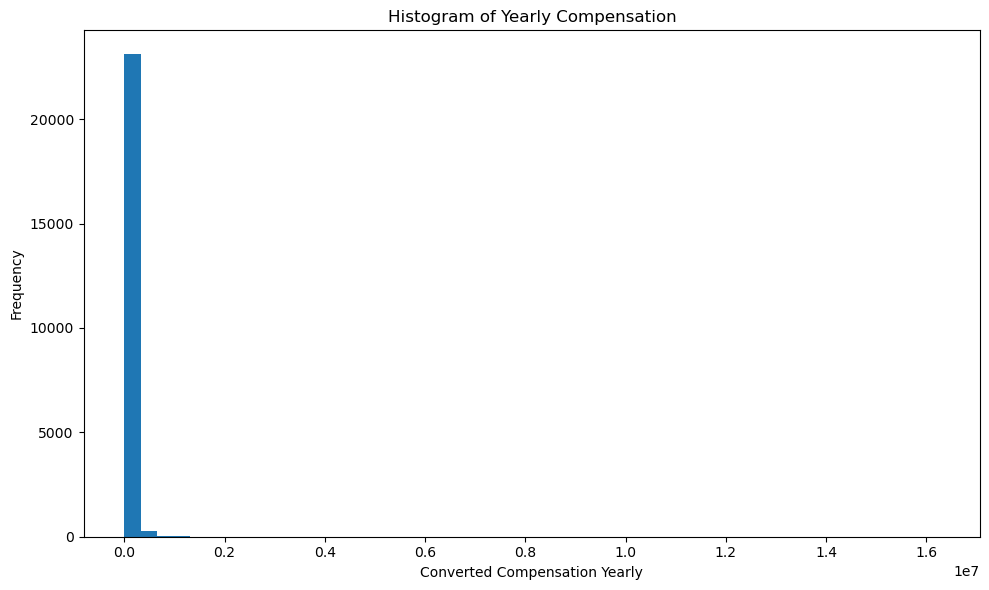

In [7]:
# Plot histogram

plt.figure(figsize=(10,6))

plt.hist(
    comp_data,
    bins=50
)

plt.title('Histogram of Yearly Compensation')
plt.xlabel('Converted Compensation Yearly')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>

**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."

In [8]:
# Filter full-time employees

full_time_df = df[
    df['Employment'] == 'Employed, full-time'
]

In [9]:
# Calculate median yearly compensation

median_compensation = full_time_df[
    'ConvertedCompYearly'
].median()

print("Median Compensation for Full-Time Employees:", median_compensation)

Median Compensation for Full-Time Employees: 69814.0


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>

Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.

In [10]:
# Select top countries with the most responses
top_countries = df['Country'].value_counts().nlargest(10).index

country_df = df[
    df['Country'].isin(top_countries)
].copy()

In [11]:
# Remove missing compensation values

country_df = country_df.dropna(
    subset=['ConvertedCompYearly']
)

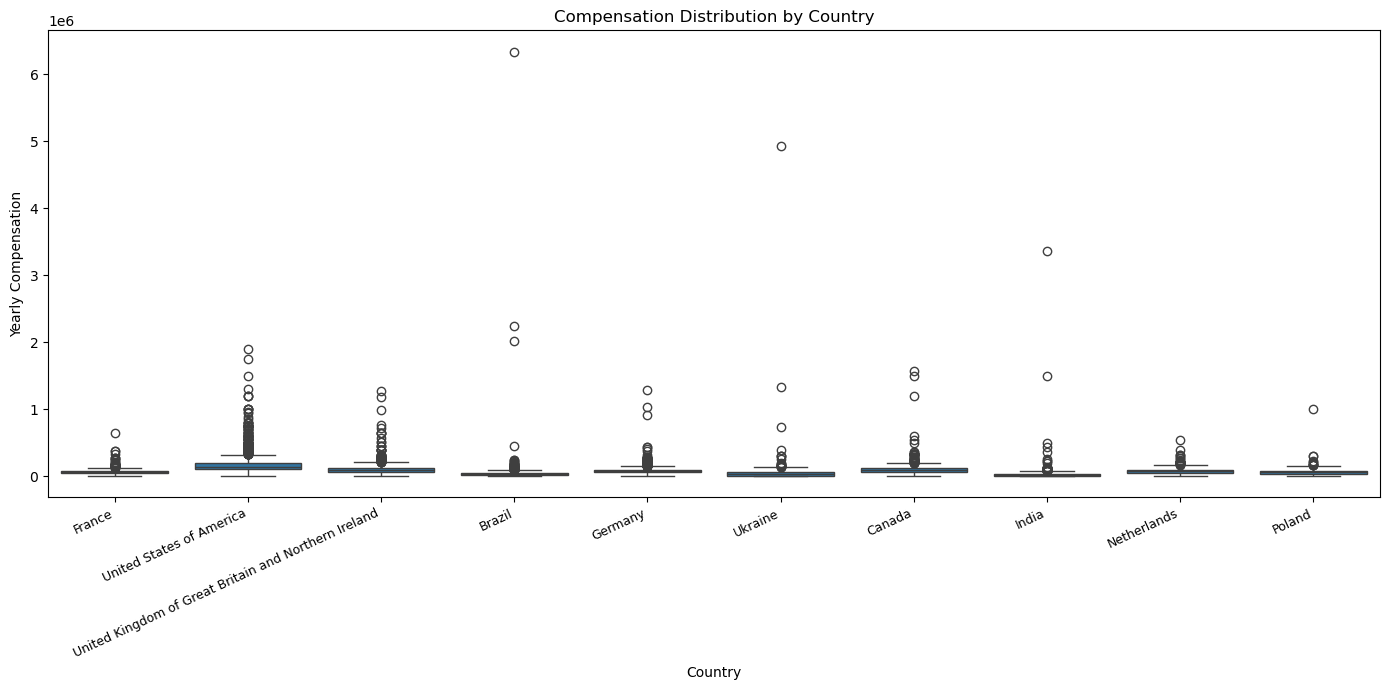

In [13]:
# Create box plot for compensation distribution by country

plt.figure(figsize=(14,7))

sns.boxplot(
    data=country_df,
    x='Country',
    y='ConvertedCompYearly'
)

plt.title('Compensation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Yearly Compensation')

plt.xticks(rotation=25, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>

**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.

In [14]:
# Calculate Q1 and Q3

Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

In [15]:
# Define lower and upper bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -80177.25
Upper Bound: 220860.75


In [16]:
# Create new dataframe without outliers

df_clean = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
].copy()

In [17]:
# Compare dataset sizes

print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_clean.shape)

Original Dataset Shape: (65437, 114)
Cleaned Dataset Shape: (22457, 114)


In [18]:
# Verify outliers removed

remaining_outliers = df_clean[
    (df_clean['ConvertedCompYearly'] < lower_bound) |
    (df_clean['ConvertedCompYearly'] > upper_bound)
]

print("Remaining Outliers:", remaining_outliers.shape[0])

Remaining Outliers: 0


<h3>Step 7: Finding Correlations Between Key Variables</h3>

**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.

In [19]:
# Convert columns to numeric

df_clean['ConvertedCompYearly'] = pd.to_numeric(
    df_clean['ConvertedCompYearly'],
    errors='coerce'
)

df_clean['WorkExp'] = pd.to_numeric(
    df_clean['WorkExp'],
    errors='coerce'
)

df_clean['JobSatPoints_1'] = pd.to_numeric(
    df_clean['JobSatPoints_1'],
    errors='coerce'
)

In [20]:
# Select required columns and remove missing values

corr_df = df_clean[
    ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
].dropna()

In [21]:
# Calculate correlation matrix

correlation_matrix = corr_df.corr()

print(correlation_matrix)

                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.406993       -0.059643
WorkExp                         0.406993  1.000000       -0.032388
JobSatPoints_1                 -0.059643 -0.032388        1.000000


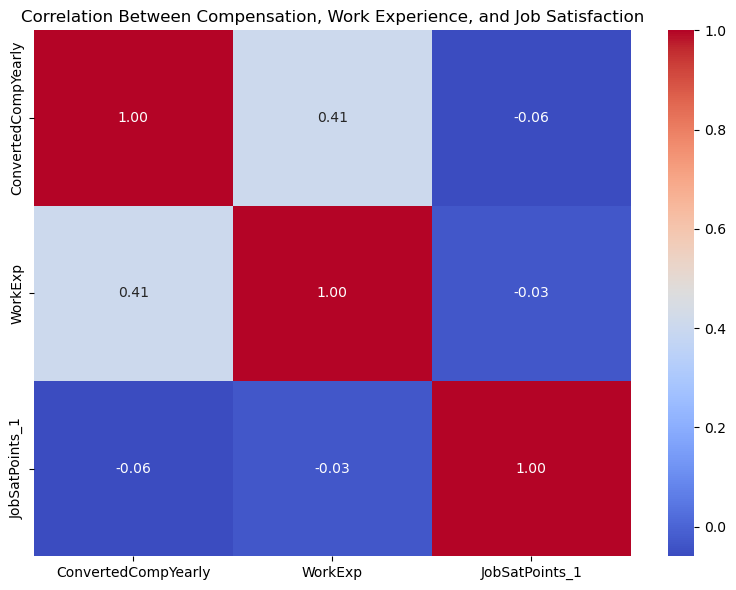

In [22]:
# Visualize correlations using heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Compensation, Work Experience, and Job Satisfaction')

plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>

**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.

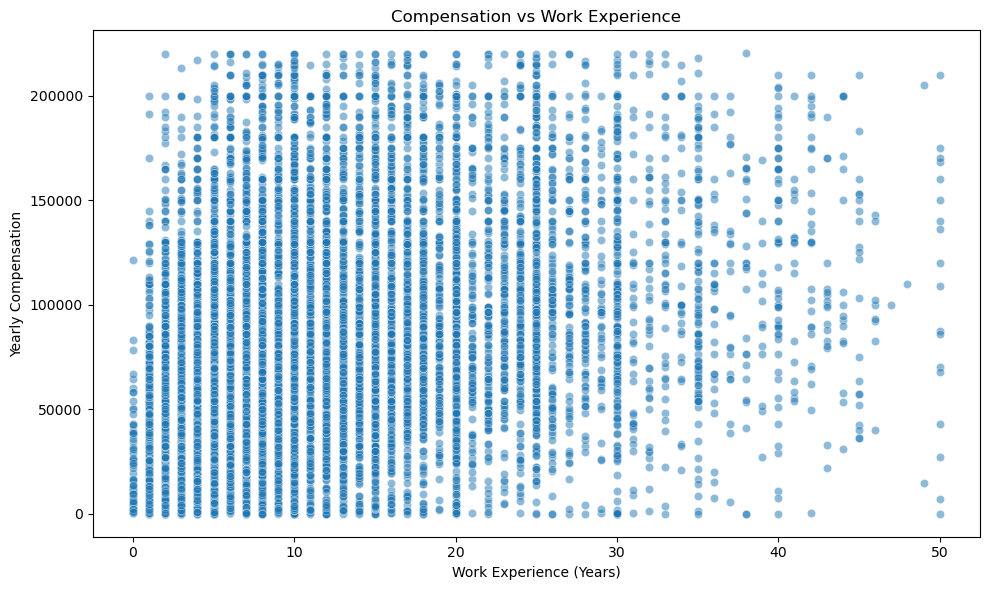

In [23]:
# Scatter plot: Compensation vs Work Experience

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='WorkExp',
    y='ConvertedCompYearly',
    alpha=0.5
)

plt.title('Compensation vs Work Experience')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Yearly Compensation')

plt.tight_layout()
plt.show()

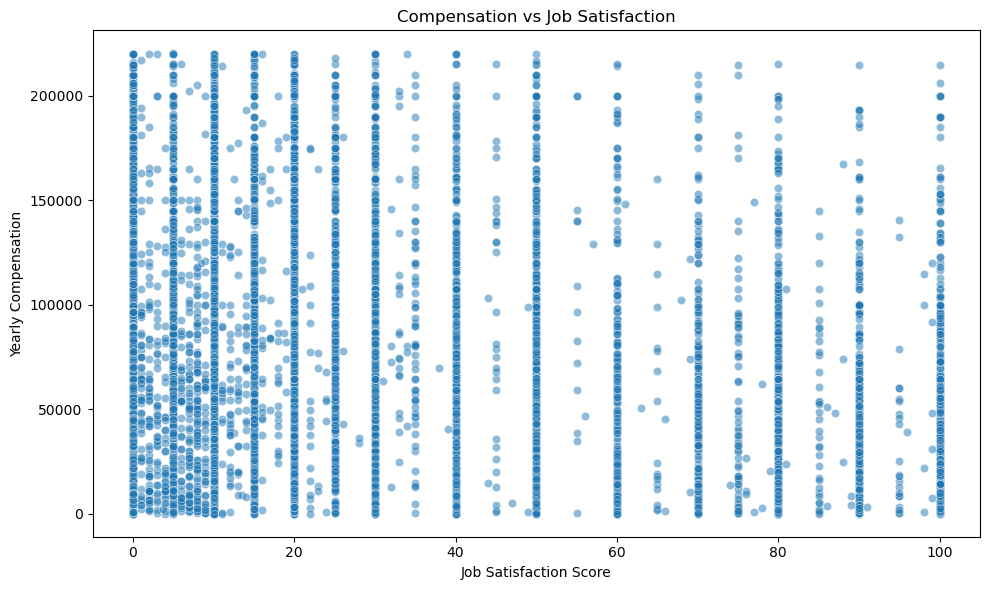

In [24]:
# Scatter plot: Compensation vs Job Satisfaction

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='JobSatPoints_1',
    y='ConvertedCompYearly',
    alpha=0.5
)

plt.title('Compensation vs Job Satisfaction')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Yearly Compensation')

plt.tight_layout()
plt.show()

<h3>Summary</h3>

In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.